<a href="https://colab.research.google.com/github/GusRaymundi/PDI/blob/main/LAB5_Filtragem_Frequencias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB5 — Filtragens no Domínio das Frequências

Disciplina: **Processamento Digital de Imagens (PDI)** – UFPel  
Professor: **Guilherme Corrêa**  

Este notebook tem com foco os conceitos de **filtragens no domínio das frequências** em imagens digitais.

---

## Objetivos  

1. Carregar e visualizar imagens em escala de cinza.
2. Transformar a imagem para o domínio das frequências usando a Transformada Discreta de Fourier (DFT).
3. Transformar a imagem de volta para o domínio espacial com a Transformada Discreta de Fourier Inversa (IDFT).
4. Realizar filtragem para suavização de imagens com filtro passa-baixas.

---

## Bibliotecas úteis
Se estiver no Colab, rode a célula de instalação uma única vez.

In [ ]:
# Se necessário no Colab, descomente a linha abaixo:
#!pip -q install numpy matplotlib scikit-image imageio

In [ ]:
# (execute uma vez)
!pip -q install ipywidgets==8.1.2 scikit-image==0.24.0 opencv-python-headless==4.10.0.84
from google.colab import output
output.enable_custom_widget_manager()

import numpy as np
import matplotlib.pyplot as plt
import cv2
from ipywidgets import interact, IntSlider
from skimage import filters, img_as_float


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.4/139.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 40.3 MB/s eta 0:00:00


## Upload de uma imagem
Usando `files` do `google.colab` para fazer upload de uma imagem.

Faça upload de uma imagem (JPG/PNG).


Saving lena_orig.bmp to lena_orig.bmp


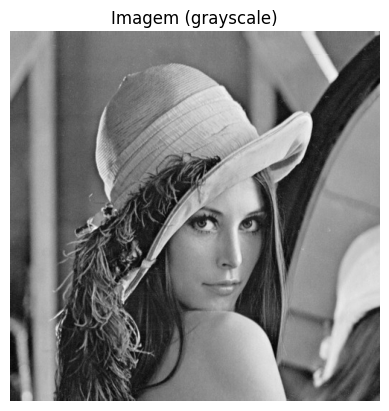

Dimensão: (497, 497)  | dtype: float64


In [ ]:
from google.colab import files

print("Faça upload de uma imagem (JPG/PNG).")
up = files.upload()
if not up:
    raise RuntimeError("Nenhum arquivo enviado.")

fname = next(iter(up))
img_bgr = cv2.imdecode(np.frombuffer(up[fname], np.uint8), cv2.IMREAD_COLOR)
if img_bgr is None:
    raise RuntimeError("Falha ao ler a imagem.")

# Converte para cinza e float [0,1]
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
img = img_as_float(img_gray)

plt.imshow(img, cmap='gray'); plt.axis('off')
plt.title('Imagem (grayscale)')
plt.show()

print("Dimensão:", img.shape, " | dtype:", img.dtype)


# 🖼️ Tarefa A — Transformar a imagem para o domínio das frequências (DFT)

Você deve:

- Utilizar a imagem em escala de cinza aberta no bloco anterior.
- Calcular a transformada de Fourier bidimensional (DFT) da imagem, utilizando as funções prontas do módulo numpy.fft.
- Centralizar o espectro de frequências com np.fft.fftshift, de modo que as baixas frequências fiquem no centro.
- Alterar o espectro de frequências para escala logarítmica (np.log1p(np.abs(...))) para melhor visualização.
- Mostrar a imagem que representa o espectro de frequências e a imagem que representa o espectro de frequências alterado para a escala logarítmica.

💡 Dicas:
- `np.fft.fft2(img)` transforma a imagem do domínio espacial para o espaço das frequências com a DFT bidimensional
- `np.fft.fftshift()` reorganiza os quadrantes do espectro, movendo a frequência zero para o centro da imagem; isso é apenas uma reordenação para facilitar a visualização e a filtragem radial.
- `np.log1p(np.abs(F))` aplica log para melhor visualização da magnitude do espectro de frequências

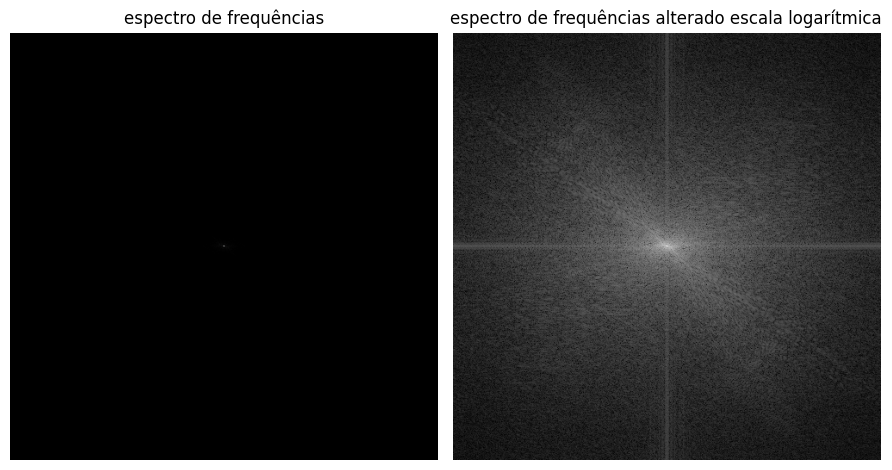

In [ ]:
F = np.fft.fft2(img)

F_shifted = np.fft.fftshift(F)

magnitude_spectrum = np.abs(F_shifted)

log_magnitude_spectrum = np.log1p(magnitude_spectrum)

plt.figure(figsize=(9, 6))

plt.subplot(1, 2, 1)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('espectro de frequências')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(log_magnitude_spectrum, cmap='gray')
plt.title('espectro de frequências alterado escala logarítmica')
plt.axis('off')

plt.tight_layout()
plt.show()

# 🖼️ Tarefa B — Transformar a imagem de volta para o domínio espacial (IDFT)

Você deve:

- Utilizar a representação no domínio das frequências do bloco anterior.
- Calcular a transformada de Fourier inversa bidimensional (IDFT) da imagem, utilizando as funções prontas do módulo numpy.fft.
- Descentralizar o espectro de frequências com `np.fft.ifftshift()`, de modo que as baixas frequências voltem ao canto esquerdo superior.
- Mostrar a imagem que representa o espectro de frequências e a imagem que representa o espectro de frequências alterado para a escala logarítmica.

💡 Dicas:
- `np.fft.ifft2(img)` transforma a imagem do domínio das frequências de volta para o dompinio espacial.
- `np.fft.ifftshift()` reorganiza os quadrantes do espectro, movendo a frequência zero de volta para o canto esquerdo superior.

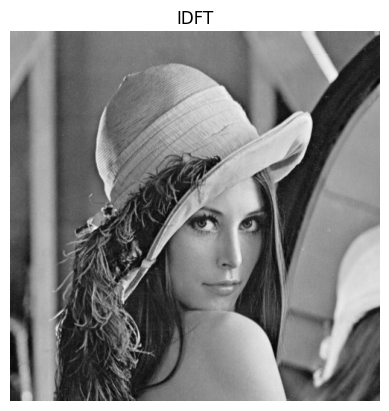

In [ ]:
F_unshifted = np.fft.ifftshift(F_shifted)

img_back = np.fft.ifft2(F_unshifted)

img_back = np.real(img_back)

plt.imshow(img_back, cmap='gray')
plt.title('IDFT')
plt.axis('off')
plt.show()

---
# 🖼️ Tarefa C — Suavização com Filtro Passa-Baixas Ideal

Você deve:

- Aplicar o filtro passa-baixas ideal.
- Mostrar o resultado do filtro passa-baixas no domínio das frequências e no domínio espacial.
- Exercite o valor de D0 para ver o resultado da suavização em diferentes níveis.

Task C: G_shifted_global updated with D0=3. Shape: (497, 497), dtype: complex128
Task C: First few values of G_shifted_global (magnitude): [0. 0. 0. 0. 0.]


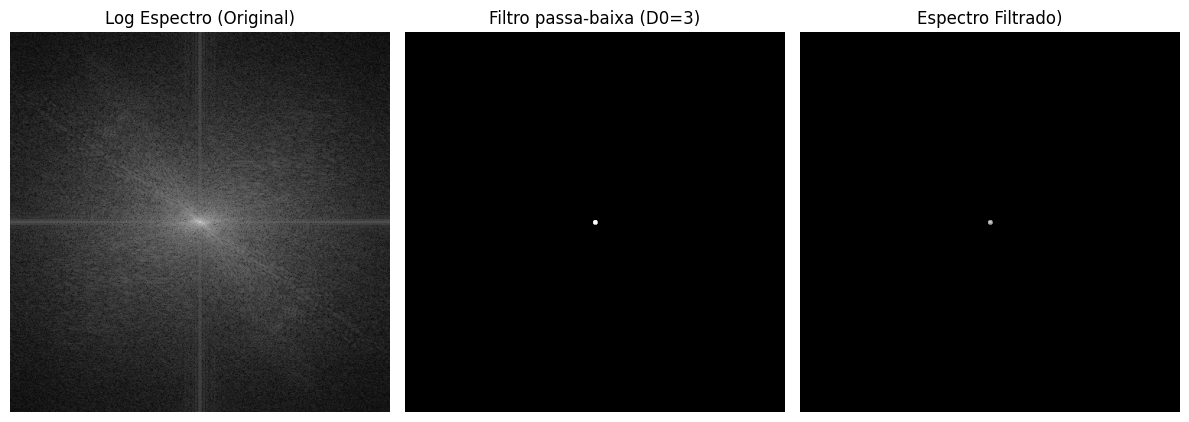

In [ ]:
def ideal_lp_mask(shape, D0):
    "Máscara passa-baixa IDEAL 2D (radial)."
    M, N = shape
    u = np.arange(M) - M/2
    v = np.arange(N) - N/2
    U, V = np.meshgrid(u, v, indexing='ij')
    D = np.sqrt(U**2 + V**2)

    H = np.zeros_like(D)
    H[D <= D0] = 1.0
    return H

# Define a global variable to store G_shifted
global G_shifted_global

def apply_ideal_lp_filter_freq(img, D0):
    global G_shifted_global
    # Calculate the 2D DFT
    F = np.fft.fft2(img)

    # Center the frequency spectrum
    F_shifted = np.fft.fftshift(F)

    # Create the ideal low-pass filter mask
    H = ideal_lp_mask(img.shape, D0)

    # Apply the mask in the frequency domain
    G_shifted_global = F_shifted * H

    print(f"Task C: G_shifted_global updated with D0={D0}. Shape: {G_shifted_global.shape}, dtype: {G_shifted_global.dtype}")
    print(f"Task C: First few values of G_shifted_global (magnitude): {np.abs(G_shifted_global).flatten()[:5]}")

    # Visualização dos resultados no domínio das frequências
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(np.log1p(np.abs(F_shifted)), cmap='gray')
    plt.axis('off')
    plt.title('Log Espectro (Original)')

    plt.subplot(1, 3, 2)
    plt.imshow(H, cmap='gray')
    plt.axis('off')
    plt.title(f'Filtro passa-baixa (D0={D0})')

    plt.subplot(1, 3, 3)
    plt.imshow(np.log1p(np.abs(G_shifted_global)), cmap='gray')
    plt.axis('off')
    plt.title('Espectro Filtrado)')

    plt.tight_layout()
    plt.show()

# Mudar valor de D
D0_value = 60
apply_ideal_lp_filter_freq(img, D0_value)

### ---
🖼️ Tarefa D — Veja o Resultado da Filtragem Passa-Baixas
Você deve:

Transformar o espectro de frequências filtrado de volta para o domínio espacial com a IFFT.
Apresentar a imagem filtrada transformada de volta para o domínio espacial.

Task D: Accessing G_shifted_global. Shape: (497, 497), dtype: complex128
Task D: First few values of G_shifted_global (magnitude): [0. 0. 0. 0. 0.]


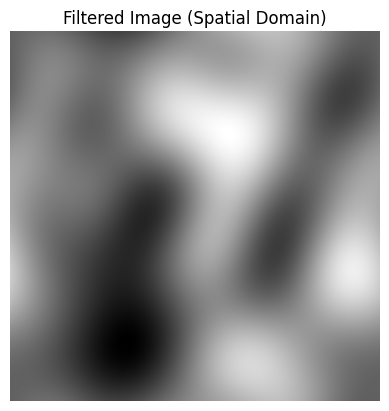

In [ ]:
# Assuming G_shifted_global is the filtered spectrum from the previous cell (Task C)

if 'G_shifted_global' in globals():
    print(f"Task D: Accessing G_shifted_global. Shape: {G_shifted_global.shape}, dtype: {G_shifted_global.dtype}")
    print(f"Task D: First few values of G_shifted_global (magnitude): {np.abs(G_shifted_global).flatten()[:5]}")


    # Shift the zero frequency component back to the top-left
    G = np.fft.ifftshift(G_shifted_global)

    # Perform the inverse 2D DFT
    img_filtered_spatial = np.fft.ifft2(G)

    # Take the real part of the result
    img_filtered_spatial = np.real(img_filtered_spatial)

    # Display the filtered image in the spatial domain
    plt.imshow(img_filtered_spatial, cmap='gray')
    plt.title('Filtered Image (Spatial Domain)')
    plt.axis('off')
    plt.show()
else:
    print("Please run the previous cell (Task C) first and interact with the slider to generate the filtered spectrum.")